## Imports


In [1]:
import gymnasium as gym
import math
import random
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


## Replay Memory for NN training

In [4]:
env = gym.make("Acrobot-v1")

# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
print(device)
Transition = namedtuple('Transition',('state', 'action', 'next_state', 'reward'))

mps


In [5]:
class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

## DQN Network ( 3- layerd feefforward Network )

In [7]:
class DQN(nn.Module):

    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, n_actions)

    # Called with either one element to determine next action, or a batch
    # during optimization. Returns tensor([[left0exp,right0exp]...]).
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)


## Network Training

In [ ]:
BATCH_SIZE = 128
GAMMA = 0.99
EPS_START = 0.9
EPS_END = 0.01
EPS_DECAY = 2500
TAU = 0.005
LR = 3e-4


# Get number of actions from gym action space
n_actions = env.action_space.n
# Get the number of state observations
state, info = env.reset()
n_observations = len(state)

print(f"Number of actions {n_actions}")
print(f"Number of Observations {n_observations}")

policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device) # This is used to compute the Target TD, the weights for this are usually frozen
target_net.load_state_dict(policy_net.state_dict()) # copies all the weights and biases of the police_net to the target_net

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(10000) # Maintaining a 10k episode memory

steps_done = 0
episode_durations = []


Number of actions 3
Number of Observations 6


In [9]:
def select_action(state):
    """
    we pick an epislon greedy action
    :param state:
    :return:
    a tensor (1,1) of d_type long, this is needed to ensure torch.gather works later while selecting the Q values from (batch_size, N-actions) from the output of policy_net(states)
    We need thus for the Bellman Loss:
    """
    global steps_done
    sample = random.random()
    # construct the eps decay based on the number of steps done
    eps_threshold = EPS_END + (EPS_START - EPS_END) * math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            # t.max(1) will return the largest column value of each row.
            # second column on max result is index of where max element was
            # found, so we pick action with the larger expected reward.
            return policy_net(state).max(1).indices.view(1, 1) # returns a named tuple with .values and .indices
    else:
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

In [11]:
def plot_durations(show_result=False):
    global episode_durations
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')
    plt.xlabel('Episode')
    plt.ylabel('Duration')
    plt.plot(durations_t.numpy())
    # Take 20 episode averages and plot them too
    if len(durations_t) >= 20:
        means = durations_t.unfold(0, 20, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(19), means))
        plt.plot(means.numpy())

    plt.pause(0.001)  # pause a bit so that plots are updated
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

In [12]:
def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    # Transpose the batch (see https://stackoverflow.com/a/19343/3343043 for
    # detailed explanation). This converts batch-array of Transitions
    # to Transition of batch-arrays.
    batch = Transition(*zip(*transitions))

    # Compute a mask of non-final states and concatenate the batch elements
    # (a final state would've been the one after which simulation ended)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # Compute Q(s_t, a) - the model computes Q(s_t), then we select the
    # columns of actions taken. These are the actions which would've been taken
    # for each batch state according to policy_net
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    # Compute V(s_{t+1}) for all next states.
    # Expected values of actions for non_final_next_states are computed based
    # on the "older" target_net; selecting their best reward with max(1).values
    # This is merged based on the mask, such that we'll have either the expected
    # state value or 0 in case the state was final.
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    # Compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Compute Huber loss
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimize the model
    optimizer.zero_grad()
    loss.backward()
    # In-place gradient clipping
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

## Post Training Analysis: Rank-Estimation

In [31]:
from dataclasses import dataclass

ACROBOT_STATE_DIMS = {
    0: "cos_theta1",
    1: "sin_theta1",
    2: "cos_theta2",
    3: "sin_theta2",
    4: "vel_theta1",
    5: "vel_theta2",
}

@dataclass
class QAnalysis:
    states:   np.ndarray   # (N, 6)  — the sampled states, acts as row index
    q_matrix: np.ndarray   # (N, 3)  — Q(s, a) for each action
    v_table:  np.ndarray   # (N,)    — V(s) = max_a Q(s, a)

    def sort_by_dim(self, dim: int) -> "QAnalysis":
        """Return a new QAnalysis sorted by a state dimension."""
        name = ACROBOT_STATE_DIMS.get(dim, f"dim_{dim}")
        print(f"Sorting by state dim {dim} ({name})")
        idx = np.argsort(self.states[:, dim])
        return QAnalysis(
            states   = self.states[idx],
            q_matrix = self.q_matrix[idx],
            v_table  = self.v_table[idx],
        )
        
    def sort_by_angle(self, dim: int) -> "QAnalysis":
        """
        Sort by recovered joint angle or velocity.
        Converts (cos, sin) pairs → angle via arctan2 before sorting.

        dim: 0 = theta1, 1 = theta2, 2 = vel_theta1, 3 = vel_theta2
        """
        ANGLE_DIMS = {
            0: ("theta1     (rad)", lambda s: np.arctan2(s[:, 1], s[:, 0])),
            1: ("theta2     (rad)", lambda s: np.arctan2(s[:, 3], s[:, 2])),
            2: ("vel_theta1 (rad/s)", lambda s: s[:, 4]),
            3: ("vel_theta2 (rad/s)", lambda s: s[:, 5]),
        }

        if dim not in ANGLE_DIMS:
            raise ValueError(f"dim must be 0–3, got {dim}")

        name, extract = ANGLE_DIMS[dim]
        print(f"Sorting by {name}")
        idx = np.argsort(extract(self.states))
        return QAnalysis(
            states   = self.states[idx],
            q_matrix = self.q_matrix[idx],
            v_table  = self.v_table[idx],
        )


    def sort_by_value(self) -> "QAnalysis":
        """Return a new QAnalysis sorted by V(s) ascending."""
        print("Sorting by V(s)")
        idx = np.argsort(self.v_table)
        return QAnalysis(
            states   = self.states[idx],
            q_matrix = self.q_matrix[idx],
            v_table  = self.v_table[idx],
        )

    def top_k(self, k: int) -> "QAnalysis":
        """Return the k states with highest V(s)."""
        idx = np.argsort(self.v_table)[-k:][::-1]
        return QAnalysis(self.states[idx], self.q_matrix[idx], self.v_table[idx])

    def bottom_k(self, k: int) -> "QAnalysis":
        """Return the k states with lowest V(s)."""
        idx = np.argsort(self.v_table)[:k]
        return QAnalysis(self.states[idx], self.q_matrix[idx], self.v_table[idx])

    def summary(self):
        print(f"States   : {self.states.shape}")
        print(f"Q-matrix : {self.q_matrix.shape}")
        print(f"V-table  : {self.v_table.shape}")
        print(f"V(s) — min: {self.v_table.min():.4f}  max: {self.v_table.max():.4f}  mean: {self.v_table.mean():.4f}")


In [32]:
def estimate_q_analysis(net: DQN, n_samples: int = 512, batch_size: int = 64,) -> QAnalysis:
    states = []

    if len(memory) > 0:
        indices = np.random.choice(
            len(memory),
            size=min(n_samples, len(memory)),
            replace=False,
        )
        for i in indices:
            tr = memory.memory[i]
            if tr.state is not None:
                states.append(tr.state.squeeze(0).cpu().numpy())

    if len(states) < n_samples:
        env_tmp = gym.make("Acrobot-v1")
        seen = set()
        try:
            while len(states) < n_samples:
                s, _ = env_tmp.reset()
                done = False
                while not done and len(states) < n_samples:
                    key = tuple(np.round(s, 6))
                    if key not in seen:
                        seen.add(key)
                        states.append(np.array(s, copy=True))
                    a = env_tmp.action_space.sample()
                    s, _, terminated, truncated, _ = env_tmp.step(a)
                    done = terminated or truncated
        finally:
            env_tmp.close()

    states_arr = np.stack(states, axis=0)    
    q_chunks   = []

    net.eval()
    with torch.no_grad():
        for start in range(0, len(states_arr), batch_size):
            s_batch = torch.tensor( states_arr[start : start + batch_size], dtype=torch.float32, device=device,)
            q_chunks.append(net(s_batch).cpu().numpy())

    q_matrix = np.concatenate(q_chunks, axis=0)  
    v_table  = q_matrix.max(axis=1)                # (N,)

    result = QAnalysis(states=states_arr, q_matrix=q_matrix, v_table=v_table)
    result.summary()
    return result

In [40]:
def build_value_tensor(analysis: QAnalysis, n_bins: int = 100) -> tuple[torch.Tensor, list]:
    """
    Discretise the 4 angle-space dims into bins and aggregate V(s)
    into a 4D tensor of shape (n_bins, n_bins, n_bins, n_bins).

    Returns:
        value_tensor : torch.Tensor  (B, B, B, B)
        bin_edges    : list of 4 np.ndarray — bin edges per dim
    """
    states  = analysis.states        
    v_table = analysis.v_table       

    # Recover angle-space coordinates
    theta1 = np.arctan2(states[:, 1], states[:, 0])   # (-π, π]
    theta2 = np.arctan2(states[:, 3], states[:, 2])   # (-π, π]
    vel1   = states[:, 4]
    vel2   = states[:, 5]

    coords     = [theta1, theta2, vel1, vel2]
    dim_names  = ["theta1", "theta2", "vel1", "vel2"]
    bin_edges  = []
    bin_ids    = []

    for i, (coord, name) in enumerate(zip(coords, dim_names)):
        edges = np.linspace(coord.min(), coord.max(), n_bins + 1)
        ids   = np.digitize(coord, edges[1:-1])
        bin_edges.append(edges)
        bin_ids.append(ids)
        print(f"{name}: [{coord.min():.3f}, {coord.max():.3f}] → {n_bins} bins")

    # Accumulate V(s) into bins (average over samples per cell)
    value_grid  = np.zeros((n_bins, n_bins, n_bins, n_bins))
    count_grid  = np.zeros_like(value_grid)

    for n in range(len(v_table)):
        i, j, k, l = bin_ids[0][n], bin_ids[1][n], bin_ids[2][n], bin_ids[3][n]
        value_grid[i, j, k, l] += v_table[n]
        count_grid[i, j, k, l] += 1

    # Fill empty bins with global mean
    empty = count_grid == 0
    value_grid[~empty] /= count_grid[~empty]
    value_grid[empty]   = v_table.mean()

    print(f"\nValue tensor shape : {value_grid.shape}")
    print(f"Empty cells        : {empty.sum()} / {n_bins**4} ({100*empty.mean():.1f}%)")

    return torch.tensor(value_grid, dtype=torch.float32), bin_edges


In [38]:
def plot_tensor_spectrum_tucker(tensor: torch.Tensor, title: str = "Tensor Spectrum (HOSVD)"):
    """
    For 2D tensors : standard SVD spectrum.
    For ND tensors : HOSVD — one singular value spectrum per mode via mode-k unfoldings.

    Args:
        tensor : torch.Tensor of 2 or more dimensions
        title  : plot title string
    """
    import tensorly as tl
    tl.set_backend("pytorch")

    t = tensor.float()

    if t.dim() < 2:
        raise ValueError("Tensor must be at least 2D.")

    mode_spectra = {}
    for k in range(t.dim()):
        unfolded  = tl.unfold(t, mode=k)
        sigmas_k  = torch.linalg.svdvals(unfolded).cpu().numpy()
        stable_rank = float((sigmas_k**2).sum() / sigmas_k[0]**2)
        mode_spectra[f"Mode {k}  (size={t.shape[k]})"] = (sigmas_k, stable_rank)

    print(f"Tensor shape : {tuple(t.shape)}")
    print(f"{'Mode':<30} {'sigma_max':>10} {'sigma_min':>10} {'Effective Rank':>12}")
    print("-" * 65)
    for mode_name, (sigmas, sr) in mode_spectra.items():
        print(f"{mode_name:<30} {sigmas[0]:>10.4f} {sigmas[-1]:>10.6f} {sr:>12.2f}")

    n_modes = len(mode_spectra)
    fig, axes = plt.subplots(1, n_modes, figsize=(5 * n_modes, 4))
    if n_modes == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=13)

    for ax, (mode_name, (sigmas, sr)) in zip(axes, mode_spectra.items()):
        ax.semilogy(sigmas, marker="o", markersize=3, linewidth=1, color="steelblue")
        ax.set_title(f"{mode_name}\nEffective rank: {sr:.2f}")
        ax.set_xlabel("Singular value index")
        ax.set_ylabel("(log scale)")
        ax.grid(True, alpha=0.3, which="both")

    plt.tight_layout()
    plt.savefig("tensor_spectrum_tucker.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved tensor_spectrum_tucker.png")


## Simulations of Learnt Policy 

In [28]:
def visualise_policy(net, episodes: int = 3):
    env_vis = gym.make("Acrobot-v1", render_mode="human")
    try:
        for ep in range(episodes):
            state, _ = env_vis.reset()
            state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            done = False
            steps = 0
            total_reward = 0.0

            while not done:
                with torch.no_grad():
                    q_vals = net(state_t)
                    action = int(q_vals.argmax(dim=1).item())
                obs, reward, terminated, truncated, _ = env_vis.step(action)
                total_reward += float(reward)
                done = terminated or truncated

                if not done:
                    state_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

                steps += 1

            print(f"Episode {ep + 1}: {steps} steps, reward {total_reward:.1f}")
    finally:
        env_vis.close()

## Main Code for trainning

Complete


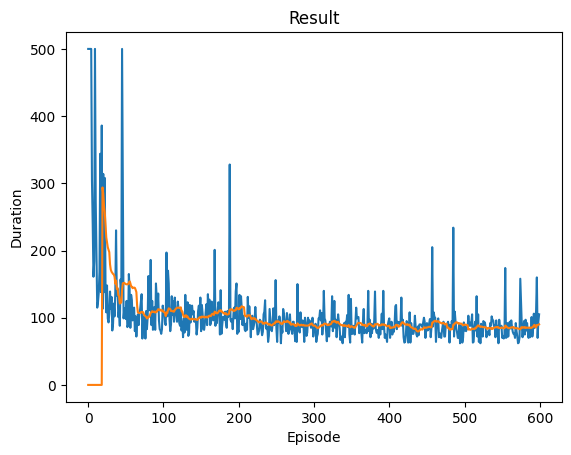

<Figure size 640x480 with 0 Axes>

In [19]:
if torch.cuda.is_available() or torch.backends.mps.is_available():
    num_episodes = 500
else:
    num_episodes = 50

for i_episode in range(num_episodes):
    # Initialize the environment and get its state
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    for t in count():
        action = select_action(state)
        observation, reward, terminated, truncated, _ = env.step(action.item())
        reward = torch.tensor([reward], device=device)
        done = terminated or truncated

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        # Store the transition in memory
        memory.push(state, action, next_state, reward)

        # Move to the next state
        state = next_state

        # Perform one step of the optimization (on the policy network)
        optimize_model()

        # Soft update of the target network's weights
        # θ′ ← τ θ + (1 −τ )θ′
        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key] * TAU + target_net_state_dict[key] * (1 - TAU)
        target_net.load_state_dict(target_net_state_dict)

        if done:
            episode_durations.append(t + 1)
            plot_durations()
            break

print('Complete')
plot_durations(show_result=True)

In [ ]:
print("\nVisualising greedy policy with learned DQN...")
visualise_policy(policy_net, episodes=1)


Visualising greedy policy with learned DQN...
Episode 1: 87 steps, reward -86.0


: 

States   : (1000000, 6)
Q-matrix : (1000000, 3)
V-table  : (1000000,)
V(s) — min: -57.2908  max: 57.0170  mean: -45.9372
Sorting by vel_theta2 (rad/s)
Tensor shape : (1000000, 3)
Mode                            sigma_max  sigma_min Effective Rank
-----------------------------------------------------------------
Mode 0  (size=1000000)         81867.6797 380.824463         1.00
Mode 1  (size=3)               81867.2734 380.824219         1.00


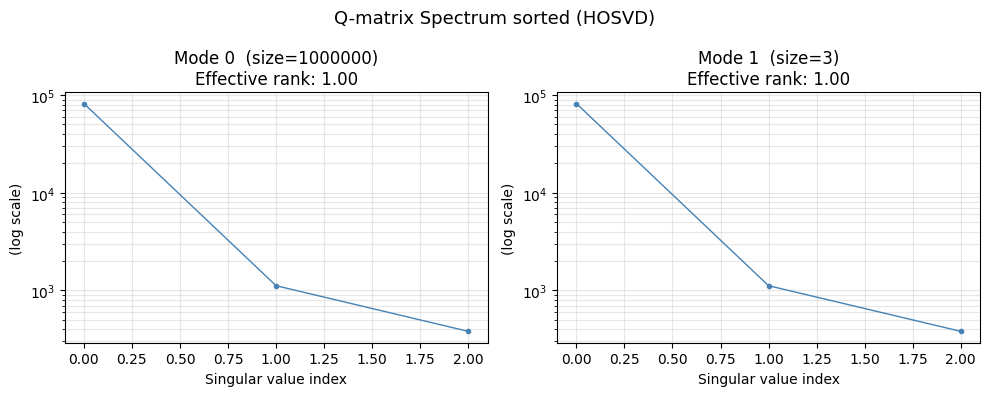

Saved tensor_spectrum_tucker.png


In [54]:
analysis    = estimate_q_analysis(policy_net, n_samples=1000000, batch_size=256)
by_theta1   = analysis.sort_by_angle(3)

# 2. Convert sorted q_matrix → torch tensor and plot its spectrum
q_tensor = torch.tensor(by_theta1.q_matrix, dtype=torch.float32)  # (N, 3)
plot_tensor_spectrum_tucker(q_tensor, title="Q-matrix Spectrum sorted (HOSVD)")


theta1: [-3.132, 3.137] → 5 bins
theta2: [-3.141, 3.141] → 5 bins
vel1: [-12.566, 8.445] → 5 bins
vel2: [-22.777, 17.219] → 5 bins

Value tensor shape : (5, 5, 5, 5)
Empty cells        : 358 / 625 (57.3%)
Tensor shape : (5, 5, 5, 5)
Mode                            sigma_max  sigma_min Effective Rank
-----------------------------------------------------------------
Mode 0  (size=5)                 822.1825 147.458359         1.32
Mode 1  (size=5)                 842.5720 161.035553         1.26
Mode 2  (size=5)                 812.1334 208.745331         1.36
Mode 3  (size=5)                 795.8964 195.650879         1.41


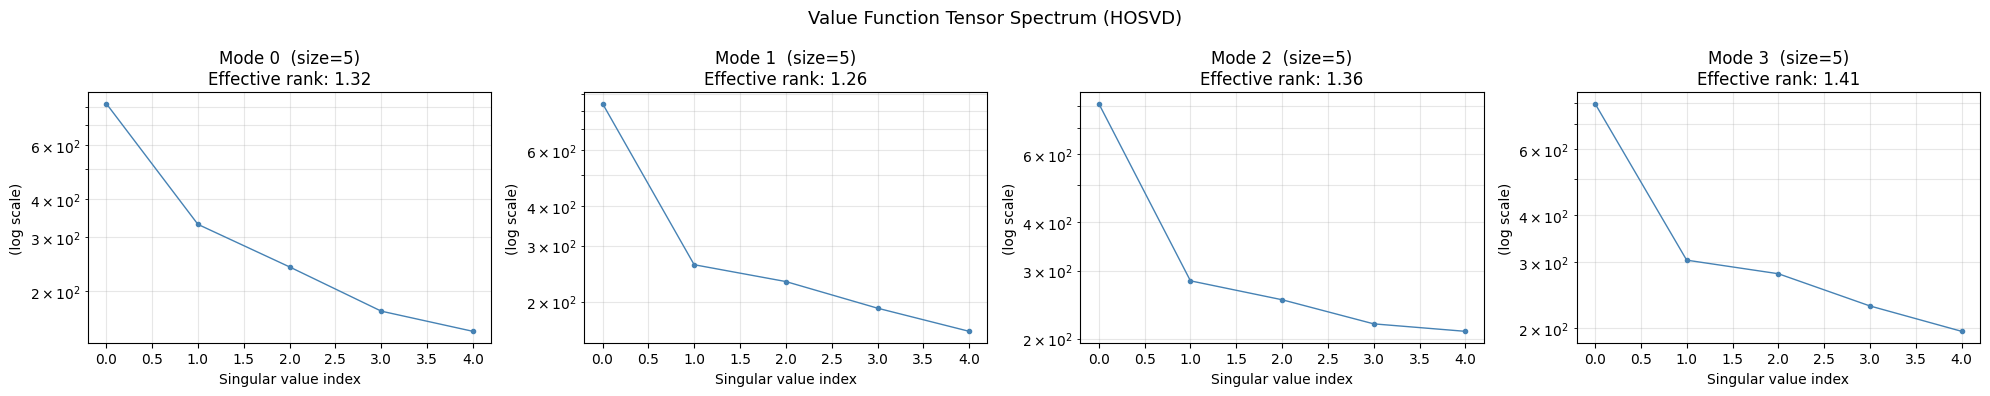

Saved tensor_spectrum_tucker.png


In [55]:
value_tensor, bin_edges = build_value_tensor(analysis, n_bins=5)
plot_tensor_spectrum_tucker(
    value_tensor,
    title="Value Function Tensor Spectrum (HOSVD)"
)


In [ ]:
# Take the state and discritisation it somehow ... take the state as 1-d values 

# fix a policy pi, for every policy generate a trajectory of value function, try to look at the Hankel matrix of the value function. 
